# PHQ-8 Depression Detection — Ensemble: Mental-RoBERTa (Text) + WavLM (Audio)

**Late-fusion ensemble** combining two pre-trained unimodal classifiers:

| Modality | Backbone | Head | Checkpoint |
|---|---|---|---|
| Text | Mental-RoBERTa (frozen) | LSTM(64) + Attention + MLP | `mental_roberta_lstm_cls_best.pth` |
| Audio | WavLM-base-plus (frozen) | LSTM(128) + Attention + MLP | `wavLM_MLP_LSTM_cls_best.pth` |

**Fusion strategies evaluated**:
1. **Simple average** — `p_ens = (p_text + p_audio) / 2`
2. **Weighted average** — `p_ens = w * p_text + (1-w) * p_audio`, weight `w` grid-searched on the validation set
3. **Logistic meta-classifier** — logistic regression trained on `[p_text, p_audio]` from the validation set (leave-one-out)

The best fusion strategy (by validation macro-F1) is applied to the test set.

## 1. Install Dependencies

In [2]:
!pip install transformers tqdm pandas numpy scikit-learn matplotlib --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [3]:
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

print("Imports successful.")

Imports successful.


In [4]:
# --- Reproducibility ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

# Feature caches from individual notebooks
TEXT_FEATURE_CACHE     = PROCESSED_DIR / "mental_roberta_features_cls.npz"
EDA_TEXT_FEATURE_CACHE = PROCESSED_DIR / "mental_roberta_features_eda_cls.npz"  # EDA-augmented training chunks
AUDIO_FEATURE_CACHE    = PROCESSED_DIR / "wavlm_features_cls.npz"

# Pre-trained model checkpoints
TEXT_CKPT  = BASE_DIR / "experiments" / "best_model" / "mental_roberta_lstm_cls" / "mental_roberta_lstm_cls_best.pth"
AUDIO_CKPT = BASE_DIR / "experiments" / "best_model" / "wavlm_mlp_lstm_cls" / "wavLM_MLP_LSTM_cls_best.pth"

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "ensemble_mentalroberta_wavlm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Global seed    : {SEED}")
print(f"Using device   : {DEVICE}")
print(f"Text cache     : {TEXT_FEATURE_CACHE.resolve()}")
print(f"EDA cache      : {EDA_TEXT_FEATURE_CACHE.resolve()}")
print(f"Audio cache    : {AUDIO_FEATURE_CACHE.resolve()}")
print(f"Text ckpt      : {TEXT_CKPT.resolve()}")
print(f"Audio ckpt     : {AUDIO_CKPT.resolve()}")

Global seed    : 42
Using device   : cuda
Text cache     : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\mental_roberta_features_cls.npz
EDA cache      : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\mental_roberta_features_eda_cls.npz
Audio cache    : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\wavlm_features_cls.npz
Text ckpt      : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\mental_roberta_lstm_cls\mental_roberta_lstm_cls_best.pth
Audio ckpt     : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\wavlm_mlp_lstm_cls\wavLM_MLP_LSTM_cls_best.pth


## 3. Load Label Files

In [5]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Load Pre-extracted Features

Both feature caches must already exist from running the individual notebooks:
- `mental_roberta_features_cls.npz` — 768-dim [CLS] chunk embeddings (text, all splits)
- `mental_roberta_features_eda_cls.npz` — EDA-augmented chunks for training participants only
- `wavlm_features_cls.npz` — 768-dim mean-pooled segment embeddings (audio)

EDA virtual participants (one per original training transcript) are merged into the training split of the text feature set. They share the same real PID base but get a unique virtual PID (`real_pid * 1000 + aug_index`). Because the audio cache has no EDA counterparts, virtual participants are automatically dropped during the inner-join alignment — so they only benefit the meta-classifier training (more real training data is unused here) but keep the pipeline consistent with the original text notebook.

In [6]:
def load_participant_features(cache_path: Path, label: str,
                               eda_cache_path: Path = None):
    """Load an .npz feature cache and group chunks by participant.

    Parameters
    ----------
    cache_path      : main feature cache (all splits)
    label           : display name for print output
    eda_cache_path  : optional EDA cache (training split only).
                      Each (pid, aug_index) pair becomes a virtual participant
                      with virtual_pid = real_pid * 1000 + aug_index.
    """
    assert cache_path.exists(), (
        f"Cache not found: {cache_path}\nRun the corresponding notebook first."
    )
    print(f"Loading {label} features from {cache_path.name} ...")
    cache = np.load(cache_path, allow_pickle=False)

    in_memory = {
        "train": defaultdict(lambda: {"feats": [], "label": None}),
        "dev":   defaultdict(lambda: {"feats": [], "label": None}),
        "test":  defaultdict(lambda: {"feats": [], "label": None}),
    }
    for feat, lbl, pid, split_b in zip(
        cache["feats"], cache["binary_labels"], cache["pids"], cache["splits"]
    ):
        split = split_b.decode()
        pid   = int(pid)
        in_memory[split][pid]["feats"].append(feat)
        in_memory[split][pid]["label"] = int(lbl)

    # Merge EDA-augmented virtual participants into the training split
    if eda_cache_path is not None:
        assert eda_cache_path.exists(), (
            f"EDA cache not found: {eda_cache_path}\nRun the text notebook first."
        )
        print(f"  Merging EDA features from {eda_cache_path.name} ...")
        eda_cache   = np.load(eda_cache_path, allow_pickle=False)
        eda_virtual = defaultdict(lambda: {"feats": [], "label": None})
        for feat, lbl, pid, aug_i in zip(
            eda_cache["feats"],
            eda_cache["binary_labels"],
            eda_cache["pids"],
            eda_cache["aug_indices"],
        ):
            virtual_pid = int(pid) * 1000 + int(aug_i)
            eda_virtual[virtual_pid]["feats"].append(feat)
            eda_virtual[virtual_pid]["label"] = int(lbl)

        for vpid, data in eda_virtual.items():
            in_memory["train"][vpid] = data

        n_eda_dep  = sum(d["label"] for d in eda_virtual.values())
        n_eda_ctrl = len(eda_virtual) - n_eda_dep
        print(f"  Added {len(eda_virtual)} EDA virtual participants to training "
              f"(depressed: {n_eda_dep}  control: {n_eda_ctrl})")

    splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

    print(f"  {'Split':10s}  {'Participants':>12}  {'Segments':>8}  {'Depressed':>9}  {'Control':>7}")
    print(f"  {'-'*52}")
    for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
        n_segs = sum(len(d["feats"]) for _, d in splits_list[s])
        n_dep  = sum(d["label"] for _, d in splits_list[s])
        n_ctrl = len(splits_list[s]) - n_dep
        print(f"  {name:10s}  {len(splits_list[s]):12d}  {n_segs:8,}  {n_dep:9d}  {n_ctrl:7d}")
    return splits_list


text_splits  = load_participant_features(
    TEXT_FEATURE_CACHE, "text (Mental-RoBERTa)", EDA_TEXT_FEATURE_CACHE
)
print()
audio_splits = load_participant_features(AUDIO_FEATURE_CACHE, "audio (WavLM)")

Loading text (Mental-RoBERTa) features from mental_roberta_features_cls.npz ...
  Merging EDA features from mental_roberta_features_eda_cls.npz ...
  Added 107 EDA virtual participants to training (depressed: 30  control: 77)
  Split       Participants  Segments  Depressed  Control
  ----------------------------------------------------
  train                214     2,049         60      154
  validation            35       354         12       23
  test                  47       519         14       33

Loading audio (WavLM) features from wavlm_features_cls.npz ...
  Split       Participants  Segments  Depressed  Control
  ----------------------------------------------------
  train                107    11,362         30       77
  validation            35     4,322         12       23
  test                  47     5,904         14       33


## 5. Model Architecture Definitions

Architectures must exactly match the saved checkpoints.

In [7]:
# ── Text model: Mental-RoBERTa LSTM + Attention + MLP ────────────────────────
TEXT_INPUT_DIM   = 768
TEXT_LSTM_HIDDEN = 64
TEXT_LSTM_LAYERS = 1
TEXT_BIDIR       = False
TEXT_MLP_HIDDEN  = 64
TEXT_DROPOUT     = 0.6


class MentalRoBERTaLSTMAttentionMLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim:     int   = TEXT_INPUT_DIM,
        lstm_hidden:   int   = TEXT_LSTM_HIDDEN,
        lstm_layers:   int   = TEXT_LSTM_LAYERS,
        bidirectional: bool  = TEXT_BIDIR,
        hidden_dim:    int   = TEXT_MLP_HIDDEN,
        dropout:       float = TEXT_DROPOUT,
    ):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        encoded    = encoded.squeeze(0)                           # (T, lstm_out_dim)
        attn_w     = torch.softmax(self.attention(encoded), dim=0)
        pooled     = (attn_w * encoded).sum(dim=0)
        pooled     = self.norm(pooled)
        return self.classifier(pooled).squeeze()


text_model = MentalRoBERTaLSTMAttentionMLPClassifier().to(DEVICE)
text_params = sum(p.numel() for p in text_model.parameters() if p.requires_grad)
print(f"Text model trainable parameters: {text_params:,}")

Text model trainable parameters: 217,922


In [8]:
# ── Audio model: WavLM LSTM + Attention + MLP ────────────────────────────────
AUDIO_INPUT_DIM   = 768
AUDIO_LSTM_HIDDEN = 128
AUDIO_LSTM_LAYERS = 1
AUDIO_BIDIR       = False
AUDIO_MLP_HIDDEN  = 128
AUDIO_DROPOUT     = 0.5


class WavLMLSTMAttentionMLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim:     int   = AUDIO_INPUT_DIM,
        lstm_hidden:   int   = AUDIO_LSTM_HIDDEN,
        lstm_layers:   int   = AUDIO_LSTM_LAYERS,
        bidirectional: bool  = AUDIO_BIDIR,
        hidden_dim:    int   = AUDIO_MLP_HIDDEN,
        dropout:       float = AUDIO_DROPOUT,
    ):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention     = nn.Linear(self.lstm_out_dim, 1)
        self.norm          = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        encoded    = encoded.squeeze(0)                           # (T, lstm_out_dim)
        attn_w     = torch.softmax(self.attention(encoded), dim=0)
        pooled     = (attn_w * encoded).sum(dim=0)
        pooled     = self.norm(pooled)
        return self.classifier(pooled).squeeze()


audio_model = WavLMLSTMAttentionMLPClassifier().to(DEVICE)
audio_params = sum(p.numel() for p in audio_model.parameters() if p.requires_grad)
print(f"Audio model trainable parameters: {audio_params:,}")

Audio model trainable parameters: 476,802


## 6. Load Pre-trained Checkpoints

In [9]:
# Text model checkpoint: saved as raw state_dict
text_state = torch.load(TEXT_CKPT, map_location=DEVICE, weights_only=True)
text_model.load_state_dict(text_state)
text_model.eval()
print(f"Text  model loaded from : {TEXT_CKPT.name}")

# Audio model checkpoint: saved as dict with 'model_state_dict' key
audio_ckpt = torch.load(AUDIO_CKPT, map_location=DEVICE, weights_only=True)
audio_model.load_state_dict(audio_ckpt["model_state_dict"])
audio_model.eval()
print(f"Audio model loaded from : {AUDIO_CKPT.name}")
print(f"  (saved at epoch {audio_ckpt['epoch']}  "
      f"val_loss={audio_ckpt['val_loss']:.4f}  "
      f"val_macro_f1={audio_ckpt['val_macro_f1']:.4f})")

Text  model loaded from : mental_roberta_lstm_cls_best.pth
Audio model loaded from : wavLM_MLP_LSTM_cls_best.pth
  (saved at epoch 15  val_loss=1.0458  val_macro_f1=0.7086)


## 7. Extract Per-participant Probabilities

Run each frozen model over its respective feature set and collect sigmoid probabilities.
Participants missing from either modality are excluded from the ensemble.

In [10]:
def get_probs(model: nn.Module, splits_list: dict, split: str) -> pd.DataFrame:
    """Return a DataFrame with columns [pid, prob, label] for the given split."""
    model.eval()
    records = []
    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            logit = model(feats)
            prob  = torch.sigmoid(logit).item()
            records.append({"pid": pid, "prob": prob, "label": data["label"]})
    return pd.DataFrame(records).set_index("pid")


def align_probs(text_df: pd.DataFrame, audio_df: pd.DataFrame) -> pd.DataFrame:
    """Inner-join on participant ID so only participants with both modalities are kept.

    EDA virtual participants (text-only) are silently dropped because they have
    no matching entry in the audio DataFrame.
    """
    merged = text_df[["prob", "label"]].rename(columns={"prob": "text_prob"}).join(
        audio_df[["prob"]].rename(columns={"prob": "audio_prob"}),
        how="inner",
    )
    n_dropped = len(text_df) - len(merged)   # participants in text but not in audio
    if n_dropped:
        print(f"  {n_dropped} text-only participant(s) dropped "
              f"(EDA virtual or missing audio).")
    return merged


# --- Training set (used to fit the meta-classifier) ---
text_train_probs  = get_probs(text_model,  text_splits,  "train")
audio_train_probs = get_probs(audio_model, audio_splits, "train")
print("Aligning training probabilities ...")
train_probs = align_probs(text_train_probs, audio_train_probs)

# --- Dev set (threshold tuning + strategy selection) ---
text_dev_probs  = get_probs(text_model,  text_splits,  "dev")
audio_dev_probs = get_probs(audio_model, audio_splits, "dev")
dev_probs       = align_probs(text_dev_probs, audio_dev_probs)

# --- Test set (final evaluation only) ---
text_test_probs  = get_probs(text_model,  text_splits,  "test")
audio_test_probs = get_probs(audio_model, audio_splits, "test")
test_probs       = align_probs(text_test_probs, audio_test_probs)

print(f"\nTrain participants with both modalities : {len(train_probs)}")
print(f"Dev   participants with both modalities : {len(dev_probs)}")
print(f"Test  participants with both modalities : {len(test_probs)}")

print("\nDev sample:")
print(dev_probs.head(5).to_string())

Aligning training probabilities ...
  107 text-only participant(s) dropped (EDA virtual or missing audio).

Train participants with both modalities : 107
Dev   participants with both modalities : 35
Test  participants with both modalities : 47

Dev sample:
     text_prob  label  audio_prob
pid                              
302   0.349588      0    0.431966
307   0.577526      0    0.465196
331   0.880217      0    0.487298
335   0.877229      1    0.509165
346   0.940212      1    0.510173


## 8. Individual Model Performance

Baseline comparison: how each unimodal model performs on its own over the aligned participant set.

In [11]:
def metrics_at_threshold(probs: np.ndarray, labels: np.ndarray, threshold: float):
    preds = (probs >= threshold).astype(int)
    return {
        "acc":       accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
        "macro_f1":  f1_score(labels, preds, average="macro", zero_division=0),
    }


def best_threshold_sweep(probs: np.ndarray, labels: np.ndarray,
                          thresholds=None) -> tuple[float, float]:
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        # labels = y_true, preds = y_pred (correct order)
        f1 = f1_score(labels, (probs >= t).astype(int), average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


y_dev = dev_probs["label"].values.astype(int)

# Text model — threshold 0.60 (from original notebook)
TEXT_THRESH  = 0.60
AUDIO_THRESH = 0.50

text_dev_m  = metrics_at_threshold(dev_probs["text_prob"].values,  y_dev, TEXT_THRESH)
audio_dev_m = metrics_at_threshold(dev_probs["audio_prob"].values, y_dev, AUDIO_THRESH)

print("Individual model performance on Dev set (aligned participants):")
print(f"{'Model':22s}  {'Threshold':>9}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'MacroF1':>8}")
print("-" * 80)
for name, m, t in [
    ("Mental-RoBERTa LSTM",  text_dev_m,  TEXT_THRESH),
    ("WavLM LSTM",           audio_dev_m, AUDIO_THRESH),
]:
    print(f"{name:22s}  {t:>9.2f}  {m['acc']:>6.4f}  "
          f"{m['precision']:>6.4f}  {m['recall']:>6.4f}  "
          f"{m['f1']:>6.4f}  {m['macro_f1']:>8.4f}")

Individual model performance on Dev set (aligned participants):
Model                   Threshold     Acc    Prec     Rec      F1   MacroF1
--------------------------------------------------------------------------------
Mental-RoBERTa LSTM          0.60  0.7714  0.7000  0.5833  0.6364    0.7348
WavLM LSTM                   0.50  0.7429  0.6364  0.5833  0.6087    0.7086


## 9. Ensemble Strategy 1 — Simple Average

`p_ens = (p_text + p_audio) / 2`. Threshold tuned on the validation set.

In [12]:
avg_dev_probs = 0.5 * dev_probs["text_prob"].values + 0.5 * dev_probs["audio_prob"].values

avg_thresh, avg_val_f1 = best_threshold_sweep(avg_dev_probs, y_dev)
avg_dev_m = metrics_at_threshold(avg_dev_probs, y_dev, avg_thresh)

print(f"Simple Average — best threshold on dev: {avg_thresh:.2f}  "
      f"(val macro-F1 = {avg_val_f1:.4f})")
print(f"  Dev  acc={avg_dev_m['acc']:.4f}  prec={avg_dev_m['precision']:.4f}  "
      f"rec={avg_dev_m['recall']:.4f}  f1={avg_dev_m['f1']:.4f}  "
      f"macro_f1={avg_dev_m['macro_f1']:.4f}")

Simple Average — best threshold on dev: 0.55  (val macro-F1 = 0.7619)
  Dev  acc=0.8000  prec=0.7778  rec=0.5833  f1=0.6667  macro_f1=0.7619


## 10. Ensemble Strategy 2 — Weighted Average

`p_ens = w * p_text + (1-w) * p_audio`. Grid-search over `w ∈ [0, 1]` and threshold on the validation set.

Weighted Average — best w_text=0.40  w_audio=0.60  threshold=0.55  val macro-F1=0.7619


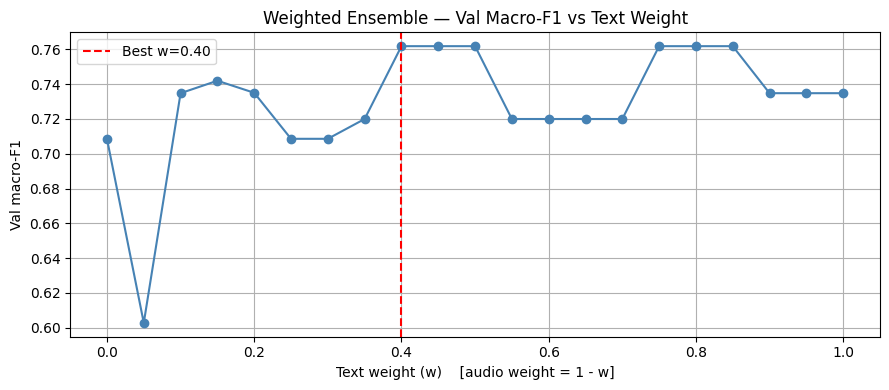

  Dev  acc=0.8000  prec=0.7778  rec=0.5833  f1=0.6667  macro_f1=0.7619


In [13]:
weight_grid  = np.arange(0.0, 1.01, 0.05)
thresh_grid  = np.arange(0.10, 0.91, 0.05)

best_w, best_t_w, best_f1_w = 0.5, 0.5, -1.0
weight_results = []

for w in weight_grid:
    ens_probs = w * dev_probs["text_prob"].values + (1 - w) * dev_probs["audio_prob"].values
    t, f1 = best_threshold_sweep(ens_probs, y_dev, thresh_grid)
    weight_results.append({"w_text": w, "w_audio": round(1 - w, 2), "threshold": t, "val_macro_f1": f1})
    if f1 > best_f1_w:
        best_f1_w = f1
        best_w    = w
        best_t_w  = t

weight_df = pd.DataFrame(weight_results)

print(f"Weighted Average — best w_text={best_w:.2f}  w_audio={1-best_w:.2f}  "
      f"threshold={best_t_w:.2f}  val macro-F1={best_f1_w:.4f}")

# Plot val macro-F1 vs text weight
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weight_df["w_text"], weight_df["val_macro_f1"], marker="o", color="steelblue")
ax.axvline(best_w, color="red", linestyle="--", label=f"Best w={best_w:.2f}")
ax.set_xlabel("Text weight (w)    [audio weight = 1 - w]")
ax.set_ylabel("Val macro-F1")
ax.set_title("Weighted Ensemble — Val Macro-F1 vs Text Weight")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

weighted_dev_probs = best_w * dev_probs["text_prob"].values + (1 - best_w) * dev_probs["audio_prob"].values
weighted_dev_m = metrics_at_threshold(weighted_dev_probs, y_dev, best_t_w)
print(f"  Dev  acc={weighted_dev_m['acc']:.4f}  prec={weighted_dev_m['precision']:.4f}  "
      f"rec={weighted_dev_m['recall']:.4f}  f1={weighted_dev_m['f1']:.4f}  "
      f"macro_f1={weighted_dev_m['macro_f1']:.4f}")

## 11. Ensemble Strategy 3 — Logistic Meta-Classifier

Fit a logistic regression on `[p_text, p_audio]` using the **training set** (107 real participants after alignment).
Threshold is tuned on the **validation set**.
This is a proper train / val / test pipeline — no LOO needed.

In [14]:
from sklearn.preprocessing import StandardScaler

# --- Fit meta-classifier on training probabilities ---
X_train = train_probs[["text_prob", "audio_prob"]].values
y_train = train_probs["label"].values.astype(int)

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)

final_meta = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
final_meta.fit(X_train_scaled, y_train)

print(f"Meta-classifier fitted on {len(X_train)} training participants.")
print(f"  text_prob  coefficient : {final_meta.coef_[0][0]:+.4f}")
print(f"  audio_prob coefficient : {final_meta.coef_[0][1]:+.4f}")
print(f"  intercept              : {final_meta.intercept_[0]:+.4f}")

# --- Tune threshold on the validation set ---
X_dev_scaled = final_scaler.transform(dev_probs[["text_prob", "audio_prob"]].values)
dev_meta_probs = final_meta.predict_proba(X_dev_scaled)[:, 1]

meta_thresh, meta_val_f1 = best_threshold_sweep(dev_meta_probs, y_dev)
meta_dev_m = metrics_at_threshold(dev_meta_probs, y_dev, meta_thresh)

print(f"\nVal macro-F1 (threshold={meta_thresh:.2f}) : {meta_val_f1:.4f}")
print(f"  Dev  acc={meta_dev_m['acc']:.4f}  prec={meta_dev_m['precision']:.4f}  "
      f"rec={meta_dev_m['recall']:.4f}  f1={meta_dev_m['f1']:.4f}  "
      f"macro_f1={meta_dev_m['macro_f1']:.4f}")

Meta-classifier fitted on 107 training participants.
  text_prob  coefficient : +2.1571
  audio_prob coefficient : +0.4780
  intercept              : -1.0085

Val macro-F1 (threshold=0.65) : 0.7619
  Dev  acc=0.8000  prec=0.7778  rec=0.5833  f1=0.6667  macro_f1=0.7619


## 12. Ensemble Comparison on Validation Set

In [15]:
strategies = [
    ("Text only (RoBERTa LSTM)",   text_dev_m,  TEXT_THRESH),
    ("Audio only (WavLM LSTM)",    audio_dev_m, AUDIO_THRESH),
    ("Ensemble: simple avg",       avg_dev_m,   avg_thresh),
    ("Ensemble: weighted avg",     weighted_dev_m, best_t_w),
    ("Ensemble: meta-classifier",  meta_dev_m,  meta_thresh),
]

print(f"\n{'Strategy':34s}  {'Thresh':>6}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'MacroF1':>8}")
print("-" * 90)
for name, m, t in strategies:
    print(f"{name:34s}  {t:>6.2f}  {m['acc']:>6.4f}  "
          f"{m['precision']:>6.4f}  {m['recall']:>6.4f}  "
          f"{m['f1']:>6.4f}  {m['macro_f1']:>8.4f}")

# Identify best ensemble strategy by validation macro-F1
best_strategy_name = max(strategies, key=lambda x: x[1]["macro_f1"])[0]
print(f"\nBest strategy on dev by macro-F1: {best_strategy_name}")


Strategy                            Thresh     Acc    Prec     Rec      F1   MacroF1
------------------------------------------------------------------------------------------
Text only (RoBERTa LSTM)              0.60  0.7714  0.7000  0.5833  0.6364    0.7348
Audio only (WavLM LSTM)               0.50  0.7429  0.6364  0.5833  0.6087    0.7086
Ensemble: simple avg                  0.55  0.8000  0.7778  0.5833  0.6667    0.7619
Ensemble: weighted avg                0.55  0.8000  0.7778  0.5833  0.6667    0.7619
Ensemble: meta-classifier             0.65  0.8000  0.7778  0.5833  0.6667    0.7619

Best strategy on dev by macro-F1: Ensemble: simple avg


## 13. Probability Calibration Plot

Scatter plot of text vs. audio probabilities on the dev set, coloured by true label.
Helps visualise how complementary the two modalities are.

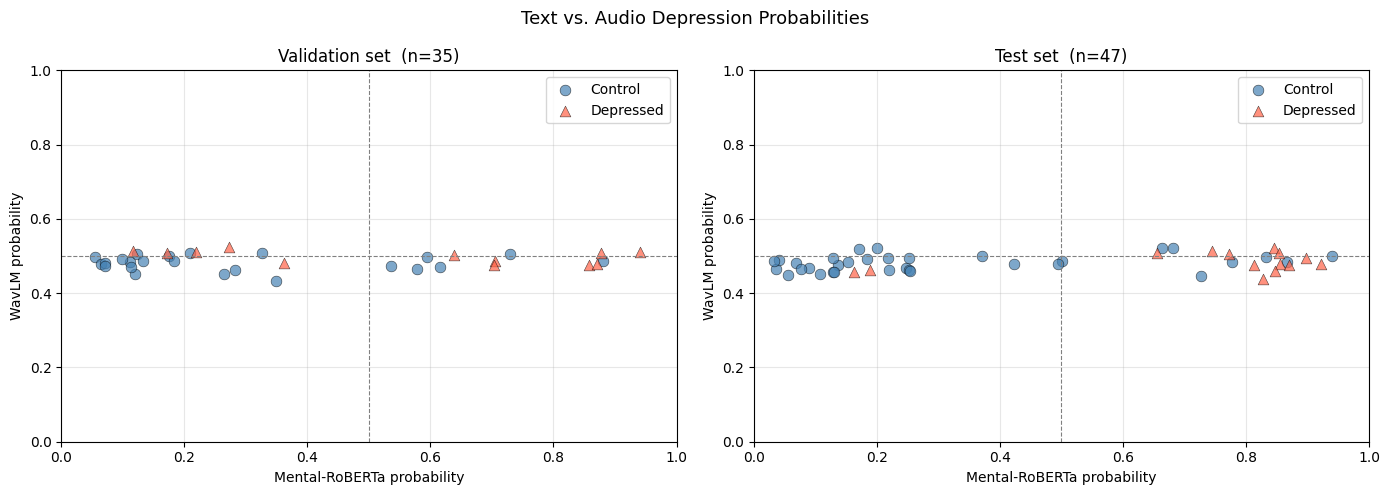

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split_probs, title) in zip(
    axes,
    [
        (dev_probs,  "Validation set"),
        (test_probs, "Test set"),
    ],
):
    ctrl = split_probs[split_probs["label"] == 0]
    dep  = split_probs[split_probs["label"] == 1]
    ax.scatter(ctrl["text_prob"], ctrl["audio_prob"],
               label="Control",   color="steelblue", alpha=0.7, s=60, edgecolors="k", linewidths=0.4)
    ax.scatter(dep["text_prob"],  dep["audio_prob"],
               label="Depressed", color="tomato",    alpha=0.7, s=60, edgecolors="k", linewidths=0.4,
               marker="^")
    ax.axvline(0.5, color="grey",  linestyle="--", linewidth=0.8)
    ax.axhline(0.5, color="grey",  linestyle="--", linewidth=0.8)
    ax.set_xlabel("Mental-RoBERTa probability")
    ax.set_ylabel("WavLM probability")
    ax.set_title(f"{title}  (n={len(split_probs)})")
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle("Text vs. Audio Depression Probabilities", fontsize=13)
plt.tight_layout()
plt.show()

## 14. Test Set Evaluation

Apply all strategies to the held-out test set using parameters tuned on the validation set.

In [17]:
y_test = test_probs["label"].values.astype(int)

# 1. Text only
text_test_m = metrics_at_threshold(test_probs["text_prob"].values, y_test, TEXT_THRESH)

# 2. Audio only
audio_test_m = metrics_at_threshold(test_probs["audio_prob"].values, y_test, AUDIO_THRESH)

# 3. Simple average
avg_test_probs = 0.5 * test_probs["text_prob"].values + 0.5 * test_probs["audio_prob"].values
avg_test_m = metrics_at_threshold(avg_test_probs, y_test, avg_thresh)

# 4. Weighted average (w tuned on val)
weighted_test_probs = best_w * test_probs["text_prob"].values + (1 - best_w) * test_probs["audio_prob"].values
weighted_test_m = metrics_at_threshold(weighted_test_probs, y_test, best_t_w)

# 5. Meta-classifier (final_meta fitted on all val data)
X_test_scaled    = final_scaler.transform(test_probs[["text_prob", "audio_prob"]].values)
meta_test_probs  = final_meta.predict_proba(X_test_scaled)[:, 1]
meta_test_m      = metrics_at_threshold(meta_test_probs, y_test, meta_thresh)

test_strategies = [
    ("Text only (RoBERTa LSTM)",   text_test_m,     TEXT_THRESH),
    ("Audio only (WavLM LSTM)",    audio_test_m,    AUDIO_THRESH),
    ("Ensemble: simple avg",       avg_test_m,      avg_thresh),
    ("Ensemble: weighted avg",     weighted_test_m, best_t_w),
    ("Ensemble: meta-classifier",  meta_test_m,     meta_thresh),
]

print(f"Test set results ({len(test_probs)} participants)\n")
print(f"{'Strategy':34s}  {'Thresh':>6}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'MacroF1':>8}")
print("-" * 90)
for name, m, t in test_strategies:
    print(f"{name:34s}  {t:>6.2f}  {m['acc']:>6.4f}  "
          f"{m['precision']:>6.4f}  {m['recall']:>6.4f}  "
          f"{m['f1']:>6.4f}  {m['macro_f1']:>8.4f}")

best_test_name = max(test_strategies, key=lambda x: x[1]["macro_f1"])[0]
print(f"\nBest strategy on test by macro-F1: {best_test_name}")

Test set results (47 participants)

Strategy                            Thresh     Acc    Prec     Rec      F1   MacroF1
------------------------------------------------------------------------------------------
Text only (RoBERTa LSTM)              0.60  0.8085  0.6316  0.8571  0.7273    0.7899
Audio only (WavLM LSTM)               0.50  0.7021  0.5000  0.3571  0.4167    0.6083
Ensemble: simple avg                  0.55  0.8085  0.6316  0.8571  0.7273    0.7899
Ensemble: weighted avg                0.55  0.8085  0.6316  0.8571  0.7273    0.7899
Ensemble: meta-classifier             0.65  0.8085  0.6316  0.8571  0.7273    0.7899

Best strategy on test by macro-F1: Text only (RoBERTa LSTM)


## 15. Detailed Classification Report — Best Ensemble

In [18]:
# Select the best strategy using VALIDATION macro-F1 (from cell-comparison),
# then report its performance on the test set — no test-set peeking.
val_strategy_names = [s[0] for s in strategies]
best_val_idx  = np.argmax([s[1]["macro_f1"] for s in strategies])
best_val_name = val_strategy_names[best_val_idx]

# Map the val-chosen strategy name to its test-set results
best_test_entry = next(s for s in test_strategies if s[0] == best_val_name)
best_name, best_m, best_t = best_test_entry

# Re-derive predictions for the chosen strategy
if best_name == "Text only (RoBERTa LSTM)":
    final_probs = test_probs["text_prob"].values
elif best_name == "Audio only (WavLM LSTM)":
    final_probs = test_probs["audio_prob"].values
elif best_name == "Ensemble: simple avg":
    final_probs = avg_test_probs
elif best_name == "Ensemble: weighted avg":
    final_probs = weighted_test_probs
else:  # meta-classifier
    final_probs = meta_test_probs

final_preds = (final_probs >= best_t).astype(int)

print(f"Best strategy (selected by val macro-F1) : {best_name}")
print(f"Threshold                                 : {best_t:.2f}")
print(f"Participants                              : {len(y_test)}\n")
print(classification_report(y_test, final_preds,
                             target_names=["Control", "Depressed"], zero_division=0))

Best strategy (selected by val macro-F1) : Ensemble: simple avg
Threshold                                 : 0.55
Participants                              : 47

              precision    recall  f1-score   support

     Control       0.93      0.79      0.85        33
   Depressed       0.63      0.86      0.73        14

    accuracy                           0.81        47
   macro avg       0.78      0.82      0.79        47
weighted avg       0.84      0.81      0.82        47



## 16. Confusion Matrices — All Strategies

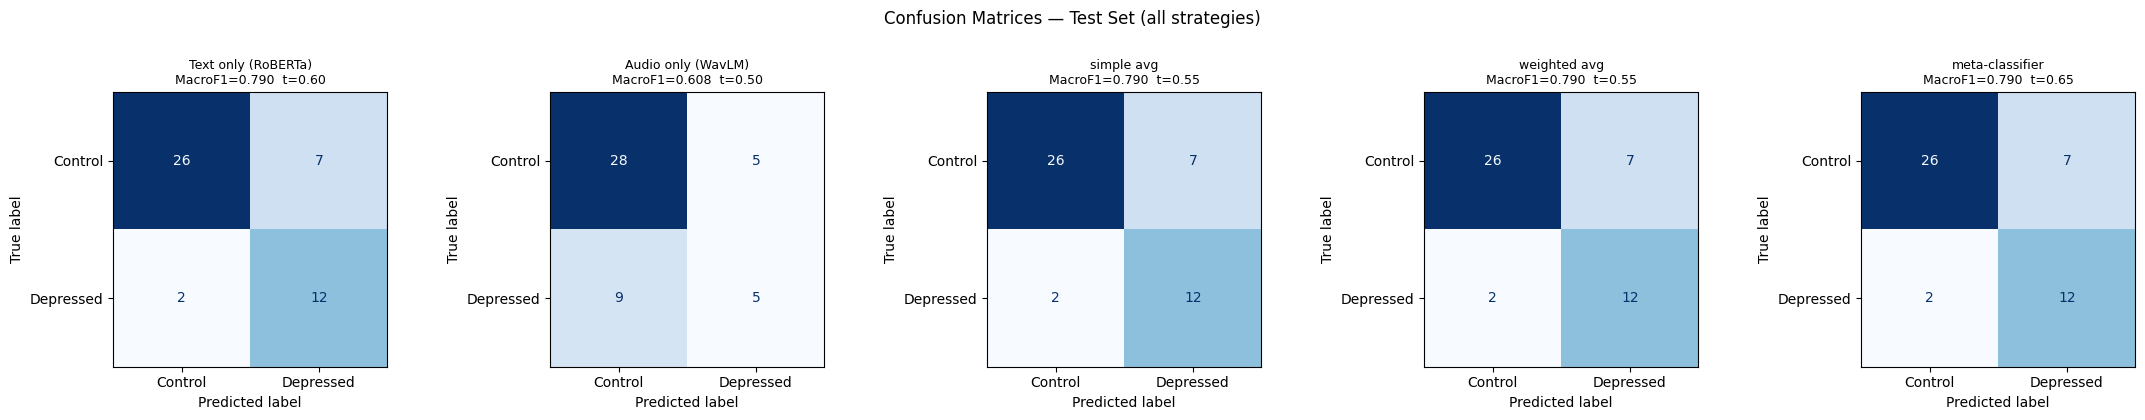

In [19]:
all_probs_test = [
    test_probs["text_prob"].values,
    test_probs["audio_prob"].values,
    avg_test_probs,
    weighted_test_probs,
    meta_test_probs,
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, m, t), probs in zip(axes, test_strategies, all_probs_test):
    preds = (probs >= t).astype(int)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Control", "Depressed"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    short_name = name.replace("Ensemble: ", "").replace(" LSTM", "")
    ax.set_title(f"{short_name}\nMacroF1={m['macro_f1']:.3f}  t={t:.2f}", fontsize=9)

plt.suptitle("Confusion Matrices — Test Set (all strategies)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 17. Probability Distribution Plot

Histogram of predicted probabilities for each strategy, split by true label.

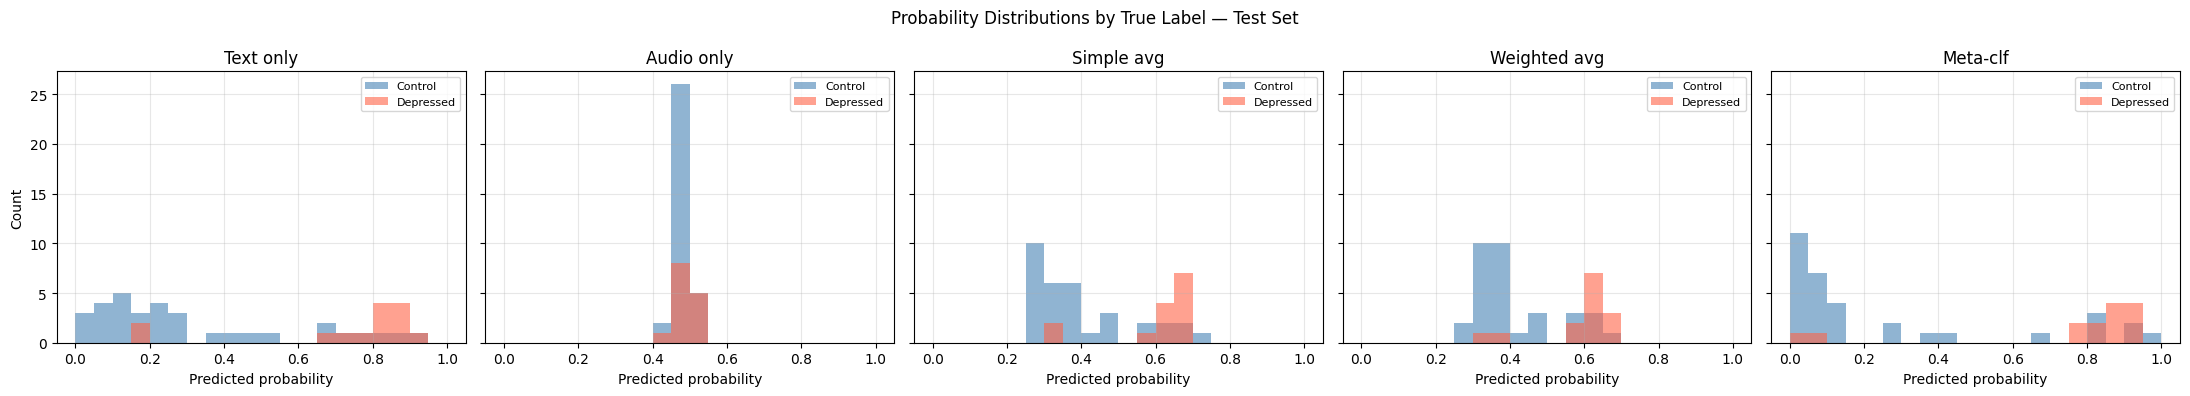

In [20]:
strategy_names_short = [
    "Text only", "Audio only", "Simple avg", "Weighted avg", "Meta-clf"
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
bins = np.linspace(0, 1, 21)

for ax, name, probs in zip(axes, strategy_names_short, all_probs_test):
    ctrl_p = probs[y_test == 0]
    dep_p  = probs[y_test == 1]
    ax.hist(ctrl_p, bins=bins, alpha=0.6, label="Control",   color="steelblue")
    ax.hist(dep_p,  bins=bins, alpha=0.6, label="Depressed", color="tomato")
    ax.set_title(name)
    ax.set_xlabel("Predicted probability")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Probability Distributions by True Label — Test Set", fontsize=12)
plt.tight_layout()
plt.show()